# Baseline Model Accuracy - IoT Packet-Loss Risk

**Input:** `network_data_cleaned_features.csv` (190,474 rows x 24 columns).

`02_model_selection_analysis.ipynb` picked Random Forest / XGBoost as the model family based on a direct head-to-head comparison there (Section 10): **Random Forest scored 0.987 PR-AUC and XGBoost 0.986, versus 0.235 for Logistic Regression**, on the same 80/20 split used here. That's the evidence behind the choice - nothing here is assumed on faith.

This notebook re-trains the same 4 candidates - Logistic Regression, Decision Tree, Random Forest, XGBoost - on a held-out test split and reports **accuracy only**, on purpose. Confusion matrices, precision/recall/F1, and tuning are deliberately left for a later notebook.

## Contents

1. Feature / target setup
2. Train/test split (80/20, stratified)
3. Encode categorical features
4. Train all 4 models and score accuracy

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

DATA_PATH = 'network_data_cleaned_features.csv'
df = pd.read_csv(DATA_PATH)
print('Shape:', df.shape)
df.head()

Shape: (190474, 24)


,src_ip,dst_ip,dst_port,proto,service,duration,src_bytes,dst_bytes,conn_state,missed_bytes,src_pkts,src_ip_bytes,dst_pkts,dst_ip_bytes,label,type,packet_lost,total_bytes,total_pkts,avg_pkt_size,ip_byte_overhead,is_incomplete_conn,conn_count_per_src_ip,dst_port_bucket
0,192.168.1.37,192.168.1.193,49178,tcp,none,290.371539,101568,2592,OTH,0,108,108064,31,3832,1,backdoor,0,104160,139,749.352518,7736,0,6374,dynamic
1,192.168.1.193,192.168.1.37,8080,tcp,none,0.000102,0,0,REJ,0,1,52,1,40,1,backdoor,0,0,2,0.000000,92,1,21708,registered
2,192.168.1.193,192.168.1.37,8080,tcp,none,0.000148,0,0,REJ,0,1,52,1,40,1,backdoor,0,0,2,0.000000,92,1,21708,registered
3,192.168.1.193,192.168.1.37,8080,tcp,none,0.000113,0,0,REJ,0,1,48,1,40,1,backdoor,0,0,2,0.000000,88,1,21708,registered
4,192.168.1.193,192.168.1.37,8080,tcp,none,0.000130,0,0,REJ,0,1,52,1,40,1,backdoor,0,0,2,0.000000,92,1,21708,registered


## Section 1 - Feature / target setup

Same exclusions as notebook 02: `missed_bytes` is dropped because it's the literal source of the target (perfect leakage), `src_ip`/`dst_ip` are dropped as high-cardinality identity columns, and `label`/`type` are dropped because they're the original intrusion-detection targets, not inputs.

In [2]:
candidate_numeric = [
    'duration', 'src_bytes', 'dst_bytes', 'src_pkts', 'dst_pkts', 'src_ip_bytes', 'dst_ip_bytes',
    'total_bytes', 'total_pkts', 'avg_pkt_size', 'ip_byte_overhead',
    'is_incomplete_conn', 'conn_count_per_src_ip',
]
candidate_categorical = ['proto', 'service', 'conn_state', 'dst_port_bucket']

X = df[candidate_numeric + candidate_categorical]
y = df['packet_lost']

print(f"Features: {len(candidate_numeric)} numeric + {len(candidate_categorical)} categorical")
print(f"Target positive rate: {y.mean()*100:.2f}%")

Features: 13 numeric + 4 categorical
Target positive rate: 1.55%


## Section 2 - Train/test split (80/20, stratified)

Stratifying on `packet_lost` keeps the same ~1.55% positive rate in both the train and test sets, matching the 80/20 split called for in the project plan.

In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print('Train shape:', X_train.shape, ' Test shape:', X_test.shape)
print(f"Train positive rate: {y_train.mean()*100:.2f}%   Test positive rate: {y_test.mean()*100:.2f}%")

Train shape: (152379, 17)  Test shape: (38095, 17)
Train positive rate: 1.55%   Test positive rate: 1.55%


## Section 3 - Encode categorical features

Numeric columns pass through unchanged; the 4 categorical columns get one-hot encoded. The encoder is fit on the training set only and just applied (`transform`) to the test set, so no information from the test set leaks into the encoding.

In [4]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer([
    ('num', 'passthrough', candidate_numeric),
    ('cat', OneHotEncoder(handle_unknown='ignore'), candidate_categorical),
])

X_train_enc = preprocessor.fit_transform(X_train)
X_test_enc = preprocessor.transform(X_test)

print('Encoded train shape:', X_train_enc.shape)
print('Encoded test shape :', X_test_enc.shape)

Encoded train shape: (152379, 42)
Encoded test shape : (38095, 42)


## Section 4 - Train all 4 models and score accuracy

Same 4 candidates as notebook 02, same `class_weight='balanced'` / `scale_pos_weight` handling for fairness. The only metric computed here is **accuracy**.

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

models = {
    'Logistic Regression': LogisticRegression(class_weight='balanced', max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(class_weight='balanced', max_depth=8, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42, n_jobs=-1),
    'XGBoost': XGBClassifier(n_estimators=200, scale_pos_weight=scale_pos_weight, eval_metric='logloss', random_state=42),
}

accuracy_results = {}
for name, model in models.items():
    model.fit(X_train_enc, y_train)
    preds = model.predict(X_test_enc)
    accuracy_results[name] = accuracy_score(y_test, preds)

accuracy_df = pd.DataFrame.from_dict(accuracy_results, orient='index', columns=['Accuracy'])
accuracy_df

C:\Users\shaad\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,Accuracy
Logistic Regression,0.943405
Decision Tree,0.990156
Random Forest,0.998346
XGBoost,0.998162


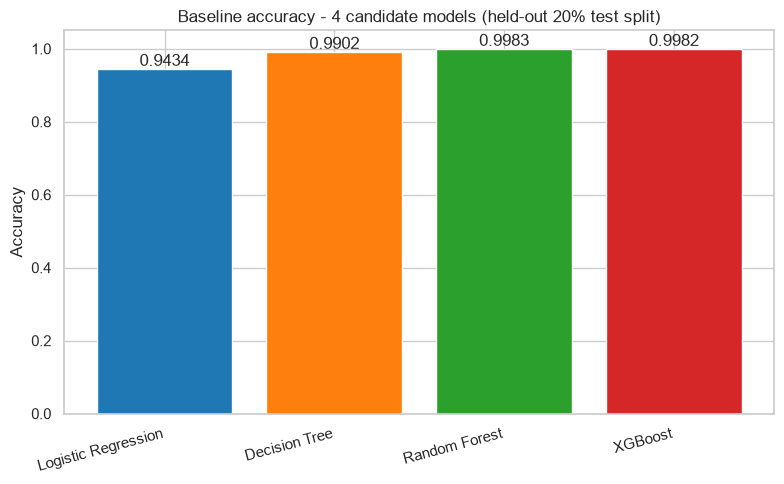

In [6]:
plt.figure(figsize=(8, 5))
bars = plt.bar(accuracy_df.index, accuracy_df['Accuracy'], color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
plt.ylabel('Accuracy')
plt.title('Baseline accuracy - 4 candidate models (held-out 20% test split)')
plt.ylim(0, 1.05)
for bar, v in zip(bars, accuracy_df['Accuracy']):
    plt.text(bar.get_x() + bar.get_width()/2, v, f'{v:.4f}', ha='center', va='bottom')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

**Note on reading these numbers:** with only 1.55% of rows positive, a model that predicts "no loss" for everything would already score ~98.45% accuracy - so a high accuracy here doesn't yet prove a model is actually catching loss events. That's exactly why confusion matrix / precision / recall / F1 are being held back for the next notebook rather than judged on accuracy alone here.